In [1]:
import pandas as pd

levels = pd.read_csv(
    "data/processed/treasury_yields.csv",
    parse_dates=["date"],
)

changes = pd.read_csv(
    "data/processed/treasury_yield_changes_bp.csv",
    parse_dates=["date"],
)

print(levels.shape)
print(changes.shape)
print(levels["date"].min())
print(levels["date"].max())

(5162, 5)
(5161, 5)
2006-02-09 00:00:00
2026-09-25 00:00:00


In [2]:
import pandas as pd
int_rate = pd.read_csv(r'C:\Users\蒋大王\Desktop\量化\Interest_rate_investment\data\processed\treasury_yield_changes_bp.csv')
int_rate

,date,d_2Y_bp,d_5Y_bp,d_10Y_bp,d_30Y_bp
0,1990-01-03,7.0,5.0,5.0,4.0
1,1990-01-04,-2.0,-1.0,-1.0,0.0
2,1990-01-05,-2.0,1.0,1.0,2.0
3,1990-01-08,0.0,0.0,3.0,3.0
4,1990-01-09,1.0,0.0,0.0,1.0
...,...,...,...,...,...
8188,2026-09-18,9.0,8.0,7.0,5.0
8189,2026-09-21,0.0,-3.0,-5.0,-5.0
8190,2026-09-22,-5.0,0.0,0.0,0.0
8191,2026-09-23,14.0,16.0,15.0,11.0


In [1]:
import pandas as pd
int_rate = pd.read_csv(r'C:\Users\蒋大王\Desktop\量化\Interest_rate_investment\data\processed\treasury_yields.csv')
int_rate

,date,2Y,5Y,10Y,30Y
0,1990-01-02,7.87,7.87,7.94,8.00
1,1990-01-03,7.94,7.92,7.99,8.04
2,1990-01-04,7.92,7.91,7.98,8.04
3,1990-01-05,7.90,7.92,7.99,8.06
4,1990-01-08,7.90,7.92,8.02,8.09
...,...,...,...,...,...
8190,2026-09-18,4.76,4.86,5.01,5.34
8191,2026-09-21,4.76,4.83,4.96,5.29
8192,2026-09-22,4.71,4.83,4.96,5.29
8193,2026-09-23,4.85,4.99,5.11,5.40


<Axes: >

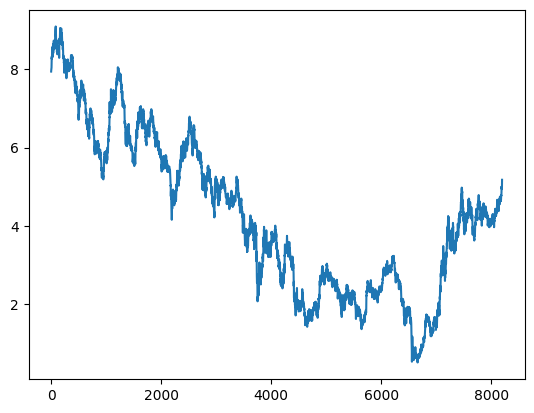

In [4]:
int_rate['10Y'].plot()

In [3]:
int_rate.describe()

,d_2Y_bp,d_5Y_bp,d_10Y_bp,d_30Y_bp
count,8193.000000,8193.000000,8193.000000,8193.000000
mean,-0.057244,-0.038081,-0.029782,-0.020383
std,5.543905,6.039726,5.761969,5.289883
min,-57.000000,-46.000000,-51.000000,-33.000000
25%,-3.000000,-3.000000,-3.000000,-3.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,2.000000,3.000000,3.000000,3.000000
max,38.000000,41.000000,39.000000,32.000000


In [4]:
int_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8193 entries, 0 to 8192
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      8193 non-null   object 
 1   d_2Y_bp   8193 non-null   float64
 2   d_5Y_bp   8193 non-null   float64
 3   d_10Y_bp  8193 non-null   float64
 4   d_30Y_bp  8193 non-null   float64
dtypes: float64(4), object(1)
memory usage: 320.2+ KB


<Axes: >

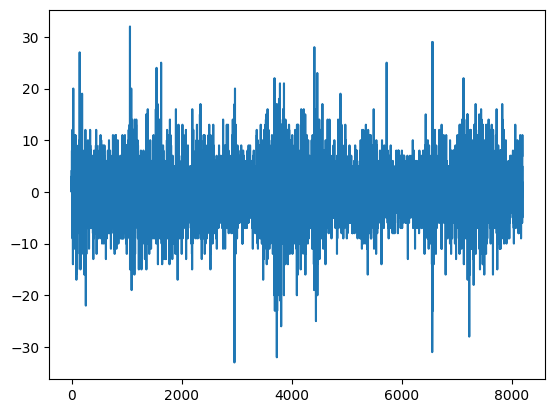

In [6]:
int_rate['d_30Y_bp'].plot()

## Data download script review

In [2]:
from __future__ import annotations

import json
import time
import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path
from typing import Dict, Iterable, List, Mapping, Sequence

import pandas as pd
import requests


TREASURY_URL = (
    "https://home.treasury.gov/resource-center/data-chart-center/"
    "interest-rates/pages/xml"
)

XML_FIELDS: Mapping[str, str] = {
    "BC_2YEAR": "2Y",
    "BC_5YEAR": "5Y",
    "BC_10YEAR": "10Y",
    "BC_30YEAR": "30Y",
}

ATOM_NS = "{http://www.w3.org/2005/Atom}"
META_NS = "{http://schemas.microsoft.com/ado/2007/08/dataservices/metadata}"
DATA_NS = "{http://schemas.microsoft.com/ado/2007/08/dataservices}"



In [6]:
def treasury_year_url(year: int) -> str:
    return (
        f"{TREASURY_URL}?data=daily_treasury_yield_curve"
        f"&field_tdr_date_value={year}"
    )
a= treasury_year_url(2020)
a

'https://home.treasury.gov/resource-center/data-chart-center/interest-rates/pages/xml?data=daily_treasury_yield_curve&field_tdr_date_value=2020'

In [8]:
def download_year(
    year: int,
    output_path: Path,
    timeout: int = 60,
    overwrite: bool = False,
    max_attempts: int = 3,
) -> Path:
    """Download one calendar year, preserving the official XML response."""
    if output_path.exists() and not overwrite:
        return output_path

    output_path.parent.mkdir(parents=True, exist_ok=True)
    headers = {"User-Agent": "Interest-rate-research/1.0"}
    last_error = None
    for attempt in range(1, max_attempts + 1):
        try:
            response = requests.get(
                treasury_year_url(year), headers=headers, timeout=timeout
            )
            response.raise_for_status()
            if b"<feed" not in response.content or b"<entry" not in response.content:
                raise ValueError(f"Treasury response for {year} contains no entries")
            output_path.write_bytes(response.content)
            return output_path
        except (requests.RequestException, ValueError) as exc:
            last_error = exc
            if attempt < max_attempts:
                time.sleep(2 ** (attempt - 1))
    raise RuntimeError(f"Failed to download Treasury data for {year}") from last_error

from pathlib import Path

output_path = Path("daily_treasury_yield_curve_2020.xml")

download_year(2020, output_path)

WindowsPath('daily_treasury_yield_curve_2020.xml')

In [6]:
PROJECT_ROOT = Path.cwd()

LEVELS_PATH = PROJECT_ROOT / "data/processed/treasury_yields.csv"
CHANGES_PATH = PROJECT_ROOT / "data/processed/treasury_yield_changes_bp.csv"
QUALITY_PATH = PROJECT_ROOT / "data/processed/treasury_data_quality.json"

print("项目目录：", PROJECT_ROOT)
print("收益率文件存在：", LEVELS_PATH.exists())
print("变化文件存在：", CHANGES_PATH.exists())
print("质量报告存在：", QUALITY_PATH.exists())

项目目录： c:\Users\蒋大王\Desktop\量化\Interest_rate_investment
收益率文件存在： True
变化文件存在： True
质量报告存在： True


In [8]:
import pandas as pd

levels = pd.read_csv(
    LEVELS_PATH,
    parse_dates=["date"]
)

changes = pd.read_csv(
    CHANGES_PATH,
    parse_dates=["date"]
)

print("收益率水平：", levels.shape)
print("收益率变化：", changes.shape)

display(levels.head())
display(changes.head())

收益率水平： (8195, 5)
收益率变化： (8193, 5)


,date,2Y,5Y,10Y,30Y
0,1990-01-02,7.87,7.87,7.94,8.00
1,1990-01-03,7.94,7.92,7.99,8.04
2,1990-01-04,7.92,7.91,7.98,8.04
3,1990-01-05,7.90,7.92,7.99,8.06
4,1990-01-08,7.90,7.92,8.02,8.09


,date,d_2Y_bp,d_5Y_bp,d_10Y_bp,d_30Y_bp
0,1990-01-03,7.0,5.0,5.0,4.0
1,1990-01-04,-2.0,-1.0,-1.0,0.0
2,1990-01-05,-2.0,1.0,1.0,2.0
3,1990-01-08,0.0,0.0,3.0,3.0
4,1990-01-09,1.0,0.0,0.0,1.0


In [9]:
print("=== 收益率水平 ===")
levels.info()

print("\n=== 收益率变化 ===")
changes.info()

=== 收益率水平 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8195 entries, 0 to 8194
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    8195 non-null   datetime64[ns]
 1   2Y      8195 non-null   float64       
 2   5Y      8195 non-null   float64       
 3   10Y     8195 non-null   float64       
 4   30Y     8195 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 320.2 KB

=== 收益率变化 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8193 entries, 0 to 8192
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      8193 non-null   datetime64[ns]
 1   d_2Y_bp   8193 non-null   float64       
 2   d_5Y_bp   8193 non-null   float64       
 3   d_10Y_bp  8193 non-null   float64       
 4   d_30Y_bp  8193 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 320.2 KB


In [10]:
levels_missing = levels.isna().sum().to_frame("missing_count")
levels_missing["missing_pct"] = (
    levels_missing["missing_count"] / len(levels) * 100
)

changes_missing = changes.isna().sum().to_frame("missing_count")
changes_missing["missing_pct"] = (
    changes_missing["missing_count"] / len(changes) * 100
)

print("=== 收益率水平缺失情况 ===")
display(levels_missing)

print("=== 收益率变化缺失情况 ===")
display(changes_missing)

=== 收益率水平缺失情况 ===


,missing_count,missing_pct
date,0,0.0
2Y,0,0.0
5Y,0,0.0
10Y,0,0.0
30Y,0,0.0


=== 收益率变化缺失情况 ===


,missing_count,missing_pct
date,0,0.0
d_2Y_bp,0,0.0
d_5Y_bp,0,0.0
d_10Y_bp,0,0.0
d_30Y_bp,0,0.0


In [11]:
with open(QUALITY_PATH, "r", encoding="utf-8") as file:
    quality_report = json.load(file)

quality_report

NameError: name 'json' is not defined

In [12]:
from src.data.treasury_yields import combine_years

raw_paths = sorted(
    (PROJECT_ROOT / "data/raw/treasury").glob(
        "daily_treasury_yield_curve_*.xml"
    )
)

print("年度 XML 数量：", len(raw_paths))

raw = combine_years(raw_paths)

print("原始数据形状：", raw.shape)
display(raw.head())

年度 XML 数量： 37
原始数据形状： (9190, 5)


,date,2Y,5Y,10Y,30Y
0,1990-01-02,7.87,7.87,7.94,8.00
1,1990-01-03,7.94,7.92,7.99,8.04
2,1990-01-04,7.92,7.91,7.98,8.04
3,1990-01-05,7.90,7.92,7.99,8.06
4,1990-01-08,7.90,7.92,8.02,8.09


In [13]:
date_gaps = levels[["date"]].copy()
date_gaps["gap_days"] = date_gaps["date"].diff().dt.days

display(
    date_gaps["gap_days"]
    .value_counts()
    .sort_index()
    .to_frame("count")
    .head(15)
)

,count
gap_days,
1.0,6391
2.0,93
3.0,1454
4.0,255
1455.0,1
